--- Optimized Assets Generated ---
optimized_output\photo2_no_metadata.jpg (360.8 KB)
optimized_output\photo2_optimized.jpg (153.4 KB)
optimized_output\photo2_optimized.webp (101.4 KB)
optimized_output\photo2_480.jpg (22.7 KB)
optimized_output\photo2_480.webp (14.6 KB)
optimized_output\photo2_768.jpg (57.8 KB)
optimized_output\photo2_768.webp (40.3 KB)
optimized_output\photo2_1200.jpg (138.0 KB)
optimized_output\photo2_1200.webp (90.7 KB)


Using CPU. Note: This module is much faster with a GPU.



Loading EasyOCR reader...


Running OCR on preprocessed image: optimized_output\photo2_no_metadata.jpg


D:\software1\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


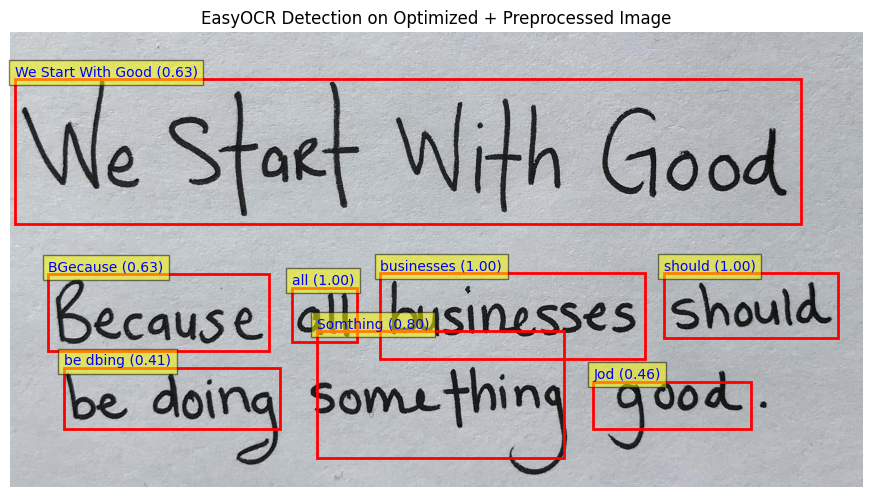


--- EasyOCR Extracted Text ---
We Start With Good
BGecause
all
businesses
should
be dbing
Somthing
Jod


In [1]:
import os
from pathlib import Path

import cv2
import easyocr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image

# ---------------------------
# Configuration
# ---------------------------
IMAGE_PATH = "photo2.jpg"
OUTPUT_DIR = Path("optimized_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Goal can be: "web", "storage", or "ocr"
OPTIMIZATION_GOAL = "ocr"

# Display size you actually need (avoid loading oversized source where possible)
DISPLAY_MAX_WIDTH = 1200
DISPLAY_MAX_HEIGHT = 1200

# Responsive variants for web delivery
RESPONSIVE_WIDTHS = [480, 768, 1200]

# ---------------------------
# Utility functions
# ---------------------------
def resize_to_fit(pil_img, max_width, max_height):
    """Resize while preserving aspect ratio; no upscaling."""
    w, h = pil_img.size
    scale = min(max_width / w, max_height / h, 1.0)
    new_size = (int(w * scale), int(h * scale))
    if new_size == pil_img.size:
        return pil_img.copy()
    return pil_img.resize(new_size, Image.Resampling.LANCZOS)


def save_jpeg(pil_img, out_path, quality=82, progressive=True):
    pil_img.convert("RGB").save(
        out_path,
        format="JPEG",
        optimize=True,
        quality=quality,
        progressive=progressive,
        subsampling="4:2:0",
    )


def save_png(pil_img, out_path):
    # Lossless PNG with optimization
    pil_img.save(out_path, format="PNG", optimize=True)


def save_webp(pil_img, out_path, quality=80):
    pil_img.save(out_path, format="WEBP", quality=quality, method=6)


def save_avif_if_available(pil_img, out_path, quality=50):
    # AVIF support depends on Pillow build; silently skip if unavailable
    try:
        pil_img.save(out_path, format="AVIF", quality=quality)
        return True
    except Exception:
        return False


def strip_metadata(img_path, output_path):
    # Re-encode pixel data only to drop EXIF and embedded thumbnails
    with Image.open(img_path) as src:
        clean = Image.fromarray(np.array(src))
        clean.save(output_path)


def generate_responsive_variants(pil_img, output_prefix):
    generated = []
    for width in RESPONSIVE_WIDTHS:
        if width >= pil_img.width:
            variant = pil_img.copy()
        else:
            h = int((width / pil_img.width) * pil_img.height)
            variant = pil_img.resize((width, h), Image.Resampling.LANCZOS)

        jpg_path = OUTPUT_DIR / f"{output_prefix}_{width}.jpg"
        webp_path = OUTPUT_DIR / f"{output_prefix}_{width}.webp"
        save_jpeg(variant, jpg_path, quality=82)
        save_webp(variant, webp_path, quality=80)
        generated.extend([jpg_path, webp_path])

    return generated


def deskew_binary(binary_img):
    # Estimate text angle from foreground pixels and rotate back
    coords = np.column_stack(np.where(binary_img > 0))
    if len(coords) < 20:
        return binary_img

    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    (h, w) = binary_img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(
        binary_img,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE,
    )


def preprocess_for_ocr(image_path):
    bgr = cv2.imread(str(image_path))
    if bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    denoised = cv2.fastNlMeansDenoising(gray, None, h=12, templateWindowSize=7, searchWindowSize=21)

    # CLAHE improves local contrast and helps faded text
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast = clahe.apply(denoised)

    # Otsu binarization works well for many OCR inputs
    _, binary = cv2.threshold(contrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    deskewed = deskew_binary(binary)
    return bgr, gray, denoised, contrast, binary, deskewed


def choose_formats(goal):
    if goal == "web":
        return ["jpeg", "webp", "avif"]
    if goal == "storage":
        return ["webp", "avif", "jpeg"]
    # OCR goal still keeps web-friendly outputs for reuse
    return ["jpeg", "webp"]


def save_optimized_master(pil_img, stem, goal):
    formats = choose_formats(goal)
    paths = []
    for fmt in formats:
        if fmt == "jpeg":
            p = OUTPUT_DIR / f"{stem}_optimized.jpg"
            save_jpeg(pil_img, p, quality=80 if goal == "storage" else 85)
            paths.append(p)
        elif fmt == "webp":
            p = OUTPUT_DIR / f"{stem}_optimized.webp"
            save_webp(pil_img, p, quality=76 if goal == "storage" else 82)
            paths.append(p)
        elif fmt == "avif":
            p = OUTPUT_DIR / f"{stem}_optimized.avif"
            if save_avif_if_available(pil_img, p, quality=45 if goal == "storage" else 55):
                paths.append(p)

    return paths


# ---------------------------
# Pipeline execution
# ---------------------------
src_path = Path(IMAGE_PATH)
if not src_path.exists():
    raise FileNotFoundError(f"Input image not found: {src_path}")

metadata_stripped_path = OUTPUT_DIR / f"{src_path.stem}_no_metadata{src_path.suffix}"
strip_metadata(src_path, metadata_stripped_path)

with Image.open(metadata_stripped_path) as img_pil:
    resized = resize_to_fit(img_pil, DISPLAY_MAX_WIDTH, DISPLAY_MAX_HEIGHT)
    master_paths = save_optimized_master(resized, src_path.stem, OPTIMIZATION_GOAL)
    variant_paths = generate_responsive_variants(resized, src_path.stem)

print("--- Optimized Assets Generated ---")
for p in [metadata_stripped_path, *master_paths, *variant_paths]:
    if p.exists():
        print(f"{p} ({p.stat().st_size / 1024:.1f} KB)")

# OCR preprocessing
orig_bgr, gray, denoised, contrast, binary, deskewed = preprocess_for_ocr(metadata_stripped_path)

# Initialize EasyOCR reader
print("\nLoading EasyOCR reader...")
reader = easyocr.Reader(["en"], gpu=False)

print(f"Running OCR on preprocessed image: {metadata_stripped_path}")
result_easyocr = reader.readtext(deskewed)

# Visualize detection on the cleaned RGB image
img_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(11, 8))
plt.imshow(img_rgb)
ax = plt.gca()

full_text_easyocr = []
for (bbox, text, prob) in result_easyocr:
    top_left = tuple(map(int, bbox[0]))
    bottom_right = tuple(map(int, bbox[2]))

    rect = patches.Rectangle(
        top_left,
        bottom_right[0] - top_left[0],
        bottom_right[1] - top_left[1],
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
    ax.add_patch(rect)

    plt.text(
        top_left[0],
        max(0, top_left[1] - 8),
        f"{text} ({prob:.2f})",
        color="blue",
        fontsize=10,
        bbox=dict(facecolor="yellow", alpha=0.5),
    )
    full_text_easyocr.append(text)

plt.title("EasyOCR Detection on Optimized + Preprocessed Image")
plt.axis("off")
plt.show()



print("\n--- EasyOCR Extracted Text ---")
if full_text_easyocr:
    print("\n".join(full_text_easyocr))
else:
    print("No text detected.")